# Linear Regression Assignment
## Medina County Career Center — AI/ML

**Your task:** Build a linear regression model from scratch using one of the datasets below.

You've seen the full process in the Auto MPG class example. Now it's your turn!

---

### Choose Your Dataset

Pick ONE of these UCI datasets. Each has a different prediction target:

| Dataset | UCI ID | What You Predict | Rows | Features | Difficulty |
|---------|--------|------------------|------|----------|------------|
| **Wine Quality** | 186 | Quality score (1-10) | 4,898 | 12 | Medium |
| **Real Estate Valuation** | 477 | House price per unit area | 414 | 6 | Easy |
| **Abalone** | 1 | Age (number of rings) | 4,177 | 8 | Medium |

---

### The Steps (follow this structure)

1. Install + import libraries
2. Load your chosen dataset from UCI
3. Explore: check shape, columns, missing values, and clean the data
4. Calculate correlations with your target variable
5. Make the correlation heatmap — **look for multicollinearity!**
6. Decide which features to keep unless the data guide has a suggestion about the variables - then follow that (or experiment)
7. Make at least ONE scatter plot of your strongest feature vs the target
8. Train/test split (80/20)
9. Build and train a LinearRegression model
10. Evaluate: print R² and MAE
11. Show the coefficients — interpret what the model learned
12. Make an actual vs predicted scatter plot

### Quick Reference — Copy and Adapt These Patterns

You don't need to switch back to the example notebook. Here are the code patterns for each step — just change the variable names and values to fit your dataset.

```python
# --- IMPORTS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from ucimlrepo import fetch_ucirepo

# --- LOAD ---
dataset = fetch_ucirepo(id=___)          # replace ___ with your UCI ID
X = dataset.data.features
y = dataset.data.targets
df = pd.concat([X, y], axis=1)

# --- EXPLORE + CLEAN ---
print(df.shape)
print(df.columns.tolist())
print(df.isnull().sum())
df = df.dropna()

# --- CORRELATIONS ---
corrMatrix = df.corr()
targetCorr = corrMatrix['your_target'].drop('your_target').sort_values()
print(targetCorr)

# --- HEATMAP ---
plt.figure(figsize=(9, 7))
sns.heatmap(corrMatrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# --- FEATURE SELECTION (if dropping columns) ---
df = df.drop(columns=['col1', 'col2'])   # drop what you don't want
X = df.drop('your_target', axis=1)
y = df['your_target']

# --- SCATTER PLOT ---
plt.figure(figsize=(8, 5))
plt.scatter(df['best_feature'], df['your_target'], alpha=0.5)
plt.xlabel('Best Feature')
plt.ylabel('Target')
plt.title('Best Feature vs Target')
plt.show()

# --- SPLIT ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- BUILD + TRAIN ---
model = LinearRegression()
model.fit(X_train, y_train)

# --- EVALUATE ---
predictions = model.predict(X_test)
r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
print(f'R² = {r2:.4f}, MAE = {mae:.2f}')

# --- COEFFICIENTS ---
coeffDf = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coeffDf = coeffDf.sort_values('Coefficient', key=abs, ascending=False)
print(coeffDf)
print(f'Intercept: {model.intercept_:.2f}')

# --- ACTUAL vs PREDICTED ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.5)
minVal = min(y_test.min(), predictions.min())
maxVal = max(y_test.max(), predictions.max())
plt.plot([minVal, maxVal], [minVal, maxVal], 'r--', linewidth=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()
```

## Step 1: Install + Import Libraries

In [1]:
%pip install ucimlrepo -q

Note: you may need to restart the kernel to use updated packages.


In [5]:
# Import your libraries here
# Hint: you need pandas, numpy, matplotlib, seaborn, sklearn stuff, ucimlrepo
# Look at the class example to get the right stuff
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from ucimlrepo import fetch_ucirepo
print("all libs loaded sucessfully")


all libs loaded sucessfully


## Step 2: Load Your Dataset

Use `fetch_ucirepo(id=___)` with the ID number from the table above.

Then get X (features) and y (target).

In [7]:
# Load your chosen dataset
# Example: dataset = fetch_ucirepo(id=186)  # for Wine Quality
dataset = fetch_ucirepo(id=186)

X = dataset.data.features
y = dataset.data.targets
df = pd.concat([X, y], axis=1)


## Step 3: Explore the Data

Print the shape, column names, first few rows, and check for missing values.

In [8]:
# Explore your data here
# - How many rows and columns?
# - What are the column names?
# - Any missing values? If so, drop them.

# We didn't use this example in our walktrhough, so providing a code snippet that 
print(f'Dtypes:\n{df.dtypes}')
print(f'\nMissing values:\n{df.isnull().sum()}')

# Some of your variables might be categorical - there are ways to deal with this, but for this exercise we'll drop them
non_numeric = df.select_dtypes(exclude='number').columns.tolist()
if non_numeric:
    print(f'\nNon-numeric columns: {non_numeric}')
    for col in non_numeric:
        print(f'  {col} unique values: {df[col].unique()}')
    print(f'\nDropping non-numeric columns for linear regression')
    df = df.drop(columns=non_numeric)

print(f'\nRows before cleaning: {len(df)}')
df = df.dropna()
print(f'Rows after cleaning:  {len(df)}')

Dtypes:
fixed_acidity           float64
volatile_acidity        float64
citric_acid             float64
residual_sugar          float64
chlorides               float64
free_sulfur_dioxide     float64
total_sulfur_dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Missing values:
fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Rows before cleaning: 6497
Rows after cleaning:  6497


## Step 4: Correlations

Calculate the Pearson r between each feature and your target. Which features have the strongest relationships?

In [28]:
# Calculate and print correlations with your target variable
corrMatrix = df.corr()
targetCorr = corrMatrix['quality'].drop('quality').sort_values()
print(targetCorr)


density                -0.305858
volatile_acidity       -0.265699
chlorides              -0.200666
fixed_acidity          -0.076743
total_sulfur_dioxide   -0.041385
residual_sugar         -0.036980
pH                      0.019506
sulphates               0.038485
free_sulfur_dioxide     0.055463
citric_acid             0.085532
alcohol                 0.444319
Name: quality, dtype: float64


## Step 5: Correlation Heatmap — Check for Multicollinearity!

Create the full correlation heatmap with ALL features. Look for:
- Which features correlate most strongly with your **target** (the thing you're predicting)?
- Which features correlate strongly with **each other**? That's multicollinearity — and you should think about whether to drop some of them.
- The rule of thumb (at least for our purposes) is if an independent variable (a predictor) has a Pearson r value of 0.7 or higher with the other variable, remove it from the model. 

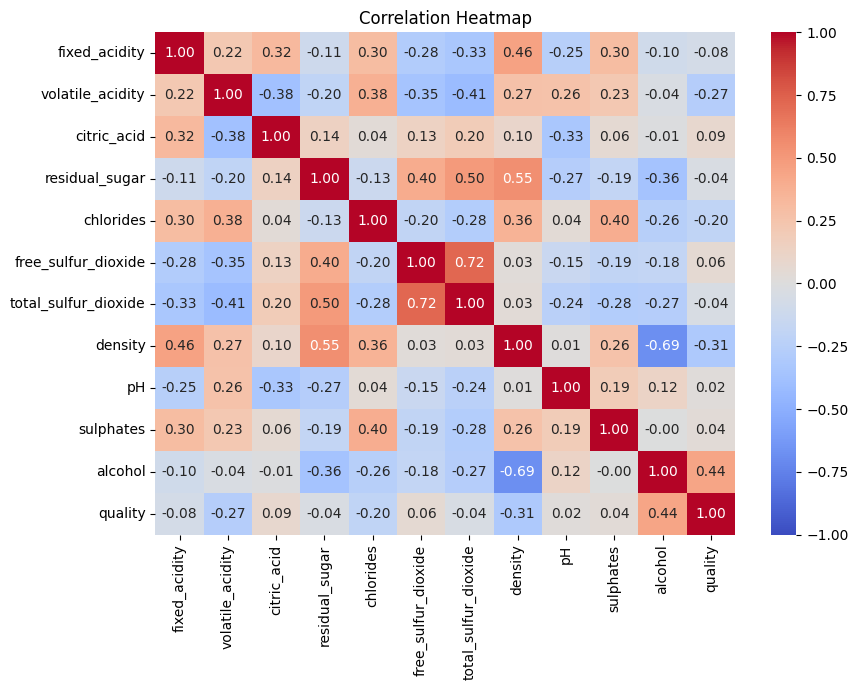

In [29]:
# Correlation heatmap — use ALL features before you decide what to drop
plt.figure(figsize=(9, 7))
sns.heatmap(corrMatrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## Step 6: Feature Selection — What Are You Keeping?

Based on the heatmap and correlations, decide which features to include in your model. You have choices:
- **Use just one feature** (simple linear regression) — easiest to interpret
- **Use a few features** — but watch out for multicollinearity between them
- **Use all features** — might get a higher R², but coefficients may be hard to explain

**In the code cell below, drop any columns you've decided to remove. In the markdown cell after that, explain WHY you made that choice.** There's no single right answer — just show that you thought about it.

In [33]:
# Drop any features you don't want to include (if any)
# Example: df = df.drop(columns=['feature1', 'feature2'])
# Then update X and y:
# X = df.drop('your_target', axis=1)
# y = df['your_target']
pdf = df.drop(columns=['density', 'pH'])   # drop what you don't want
X = df.drop('quality', axis=1)
y = df['quality']

**My feature selection decision:** *(explain here — what did you keep, what did you drop, and why?)*
Density because it can already be calculated, and pH because it has the lowest pearson R value



## Step 7: Scatter Plot

Create a scatter plot showing your strongest-correlated feature vs the target.

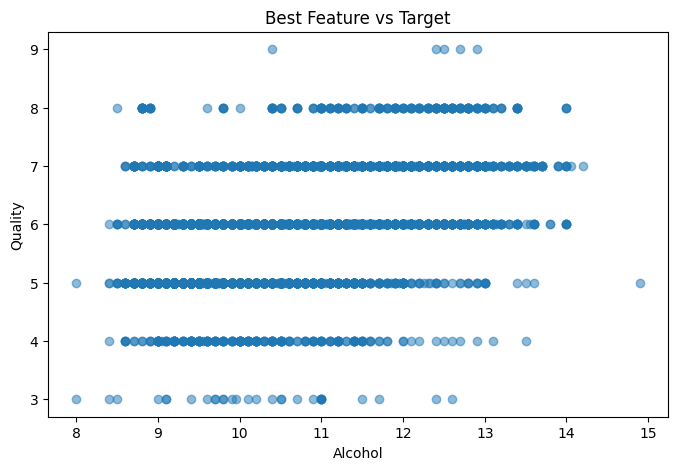

In [35]:
# Scatter plot: strongest feature vs target
plt.figure(figsize=(8, 5))
plt.scatter(df['alcohol'], df['quality'], alpha=0.5)
plt.xlabel('Alcohol')
plt.ylabel('Quality')
plt.title('Best Feature vs Target')
plt.show()


## Step 8: Train/Test Split

In [36]:
# Split 80% train, 20% test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Step 9: Build and Train the Model

In [37]:
# Create a LinearRegression model and fit it
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Step 10: Evaluate

Print R² and MAE. Write a sentence interpreting what they mean for your dataset.

In [39]:
# Make predictions on test data and calculate R² and MAE
predictions = model.predict(X_test)
r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
print(f'R² = {r2:.4f}, MAE = {mae:.2f}')


R² = 0.2598, MAE = 0.57


## Step 11: Coefficients

Display the coefficients. Which features have the biggest effect? Are they positive or negative? Do any of the signs surprise you? (Remember what we saw with multicollinearity in the class example.)

In [40]:
# Show coefficients and interpret them

coeffDf = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coeffDf = coeffDf.sort_values('Coefficient', key=abs, ascending=False)
print(coeffDf)
print(f'Intercept: {model.intercept_:.2f}')

                 Feature  Coefficient
7                density   -58.945052
1       volatile_acidity    -1.350775
9              sulphates     0.808360
8                     pH     0.482842
4              chlorides    -0.332842
10               alcohol     0.270669
2            citric_acid    -0.143778
0          fixed_acidity     0.078975
3         residual_sugar     0.045949
5    free_sulfur_dioxide     0.007025
6   total_sulfur_dioxide    -0.002663
Intercept: 59.42


## Step 12: Actual vs Predicted Plot

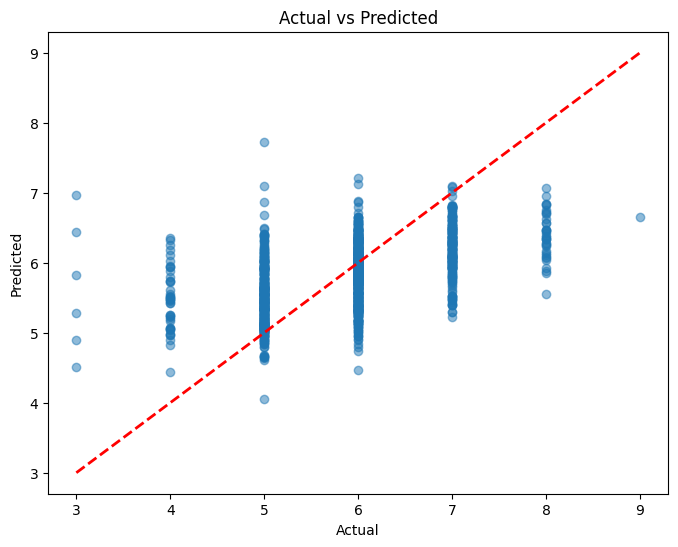

In [41]:
# Scatter plot: actual vs predicted with the red dashed "perfect" line
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.5)
minVal = min(y_test.min(), predictions.min())
maxVal = max(y_test.max(), predictions.max())
plt.plot([minVal, maxVal], [minVal, maxVal], 'r--', linewidth=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()


## Reflection (answer in this cell)

1. What dataset did you choose and why?
2. What was your R² score? Do you think that is good or bad, considering your dataset?
3. Which feature had the strongest correlation with your target?
4. Did you see any multicollinearity in your heatmap? What did you do about it — did you drop any features? Why or why not?
5. Look at your coefficients — do any of the signs (positive/negative) surprise you or seem to contradict what you'd expect? If so, what might explain that?
6. If you wanted to improve this model, what would you try next?